# Evapotranspiration Analysis of Pistachio Orchard
Bases on the FAO-56 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, date
import warnings, re, traceback

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "DejaVu Sans"

## Physical & Local Constants

In [2]:
phi = np.radians(35.2875)       # Latitude (radians) - Torbat-e Heydarieh
L_z = 52.5                      # Standard meridian for IRST (E)
L_m = 59.2215                   # Longitude of measurement site (E)
t_0 = 10 / 60                   # Measurement interval (hours)
G_sc = 0.0820                   # Solar constant (MJ/m^2/min)
z = 1500                        # Elevation (m above sea level)
alpha = 0.20                    # Albedo for pistachio orchard (0.20-0.22)
sigma = 4.903e-9                # Stefan-Boltzmann constant (MJ/K^4/m^2/day)
c_s = 1.2                       # Soil specific heat (MJ/m^3/°C)


## Pistachio Parameters

In [3]:
Kc_ini = 0.40                   # Initial stage Kc
Kc_mid = 1.10                   # Mid-season Kc
Kc_end = 0.70                   # End-season Kc
tree_height = 3.5               # Pistachio tree height (m)
root_depth_max = 1.5            # Maximum root depth (m)
p_depletion = 0.40              # Depletion fraction for pistachio

# Soil parameters (typical loam for pistachio regions)
theta_FC = 0.28                 # Field capacity
theta_WP = 0.12                 # Wilting point
Ze = 0.10                       # Evaporation layer depth (m)

## Atmospheric Functions

$$
\Large
e^{\circ}(T) = 0.6108 \cdot \exp\left(\frac{17.27 \cdot T}{T + 237.3}\right)
\\[1em]
e_s = \frac{e^{\circ}(T_{max}) + e^{\circ}(T_{min})}{2}
\\[1em]
e_a = \frac{e^{\circ}(T_{min}) \cdot \frac{RH_{max}}{100} + e^{\circ}(T_{max}) \cdot \frac{RH_{min}}{100}}{2}
\\[1em]
\Delta = \frac{4098 \cdot e_s}{(T + 237.3)^2}
\\[1em]
\gamma = \frac{c_p \cdot P}{\varepsilon \cdot \lambda} = 0.665 \times 10^{-3} \cdot P
\\[1em]
$$

$e^{\circ}$: Saturated vapor pressure  
$e_s$: Mean Saturated Vapor Pressure  
$e_a$: Actual Vapor Pressure  
$RH$: Relative Humidity  
$\Delta$: Slope of saturation vapor pressure curve  
$\gamma$: Psychrometric constant



In [4]:
def e_sat(T: float) -> float:
    """Saturated vapor pressure (kPa)"""
    return 0.6108 * np.exp((17.27 * T) / (T + 237.3))

def calc_e_s(T_max: float, T_min: float) -> float:
    """Mean saturated vapor pressure (kPa)"""
    return (e_sat(T_max) + e_sat(T_min)) / 2

def calc_e_a(T_min: float, T_max: float, RH_min: float, RH_max: float) -> float:
    """Actual vapor pressure (kPa)"""
    return (e_sat(T_min) * RH_max/100 + e_sat(T_max) * RH_min/100) / 2

def calc_Delta(T: float) -> float:
    """Slope of saturation vapor pressure curve (kPa/C)"""
    es = e_sat(T)
    return 4098 * es / ((T + 237.3) ** 2)

def calc_gamma(P: float) -> float:
    """Psychrometric constant (kPa/C)"""
    a_psy = 1.013e-3 / 0.622 / 2.45
    return a_psy * P


## Solar Geometry Functions


$$
\Large
\delta = 0.409 \cdot \sin\left(\frac{2\pi}{365} \cdot J - 1.39\right) 
\\[1em]
d_r = 1 + 0.033 \cdot \cos\left(\frac{2\pi}{365} \cdot J\right)
\\[1em]
b = \frac{2\pi \cdot (J - 81)}{364}
\\[1em]
S_c = 0.1645 \cdot \sin(2b) - 0.1255 \cdot \cos(b) - 0.025 \cdot \sin(b)
\\[1em]
\omega = \frac{\pi}{12} \left[(t + 0.06667 \cdot (L_z - L_m) + S_c) - 12\right]
\\[1em]
\omega_s = \arccos(-\tan\phi \cdot \tan\delta)
\\[1em]
$$

$\delta$: Solar Declination  
$d_r$: Inverse Relative Earth-Sun Distance  
$S_c$: Seasonal Correction  
$\omega$: Solar Time Angle at Midpoint  
$\omega_s$: Sunset Hour Angle

In [5]:
def calc_delta_solar(day: int) -> float:
    """Solar declination (radians)"""
    return 0.409 * np.sin(2 * np.pi * day / 365 - 1.39)

def calc_d_r(day: int) -> float:
    """Inverse relative Earth-Sun distance"""
    return 1 + 0.033 * np.cos(2 * np.pi * day / 365)

def calc_S_c(day: int) -> float:
    """Seasonal correction for solar time (hours)"""
    b = 2 * np.pi / 364 * (day - 81)
    S_c = 0.1645 * np.sin(2*b) - 0.1255 * np.cos(b) - 0.025 * np.sin(b)
    return S_c

def calc_omega(t: float, day: int) -> float:
    """Solar time angle at midpoint (radians)"""
    S_c = calc_S_c(day)
    omega = np.pi/12 * ((t + 0.06667*(L_z - L_m) + S_c) - 12)
    return omega

def calc_sunset_hour_angle(day: int) -> float:
    """Sunset hour angle (radians)"""
    delta = calc_delta_solar(day)
    return np.arccos(-np.tan(phi) * np.tan(delta))

## Radiation Functions

$$\large
R_a = \frac{12 \times 64}{\pi} \cdot G_{sc} \cdot d_r \cdot \left[(\omega_2 - \omega_1) \cdot \sin\phi \cdot \sin\delta + \cos\phi \cdot \cos\delta \cdot (\sin\omega_2 - \sin\omega_1)\right]
\\
\omega_1 = \omega - \frac{\pi \cdot t_i}{24}, \quad
\omega_2 = \omega + \frac{\pi \cdot t_i}{24}
\\[1em]
R_s = \left(0.25 + 0.50 \cdot \frac{n}{N}\right) \cdot R_a
\\
N = \frac{24}{\pi} \cdot \omega_s
\\[1em]
R_{so} = (0.75 + 2 \times 10^{-5} \cdot z) \cdot R_a
\\[1em]
R_{ns} = (1 - \alpha) \cdot R_s
\\[1em]
R_{nl} = \sigma \cdot \left(\frac{T_{max,K}^4 + T_{min,K}^4}{2}\right) \cdot (0.34 - 0.14 \cdot \sqrt{e_a}) \cdot \left(1.35 \cdot \frac{R_s}{R_{so}} - 0.35\right)
\\[1em]
R_n = R_{ns} - R_{nl}
$$

$R_a$: Extraterrestrial Radiation  
$R_s$: Solar Radiation from Sunshine Hours  
$N$: Maximum sunshine hours  
$R_{so}$: Clear-Sky Solar Radiation  
$R_{ns}$: Net Shortwave Radiation  
$R_{nl}$: Net Longwave Radiation  
$\sigma$: Stefan-Boltzmann constant  
$R_n$: Net Radiation  

In [6]:
def calc_R_a_interval(t: float, day: int, interval: float=t_0) -> float :
    """Extraterrestrial radiation for sub-hourly period (MJ/m^2/period)"""
    omega_mid = calc_omega(t, day)
    omega_1 = omega_mid - np.pi * interval / 24
    omega_2 = omega_mid + np.pi * interval / 24
    
    d_r = calc_d_r(day)
    delta = calc_delta_solar(day)
    omega_s = calc_sunset_hour_angle(day)
    
    # Clip to sunrise/sunset
    if omega_2 <= -omega_s or omega_1 >= omega_s:
        return 0.0
    
    omega_1 = max(omega_1, -omega_s)
    omega_2 = min(omega_2, omega_s)
    
    if omega_1 >= omega_2:
        return 0.0
    
    R_a = (12 * 60 / np.pi) * G_sc * d_r * (
        (omega_2 - omega_1) * np.sin(phi) * np.sin(delta) +
        np.cos(phi) * np.cos(delta) * (np.sin(omega_2) - np.sin(omega_1))
    )
    
    return max(R_a, 0)

def calc_R_a_daily(day: int) -> float:
    """Daily extraterrestrial radiation (MJ/m^2/day)"""
    d_r = calc_d_r(day)
    delta = calc_delta_solar(day)
    omega_s = calc_sunset_hour_angle(day)
    
    R_a = (24 * 60 / np.pi) * G_sc * d_r * (
        omega_s * np.sin(phi) * np.sin(delta) +
        np.cos(phi) * np.cos(delta) * np.sin(omega_s)
    )
    return R_a

def calc_N(day: int) -> float:
    """Maximum sunshine hours"""
    omega_s = calc_sunset_hour_angle(day)
    return 24 / np.pi * omega_s

def calc_R_s(day: int, n: int) -> float:
    """Solar radiation from sunshine hours (MJ/m^2/day)"""
    N = calc_N(day)
    R_a_val = calc_R_a_daily(day)
    if N > 0 and n > 0:
        return (0.25 + 0.50 * n/N) * R_a_val
    return 0

def calc_R_so(day: int) -> float:
    """Clear-sky solar radiation (MJ/m^2/day)"""
    R_a_val = calc_R_a_daily(day)
    return (0.75 + 2e-5 * z) * R_a_val

def calc_R_n(R_s: float, t: float, day: int, T: float, RH: float) -> float:
    """Net radiation for sub-hourly period (MJ/m^2/period)"""
    # Convert measured solar from W/m^2 to MJ/m^2/period
    R_s_MJ = R_s * t_0 * 3600 / 1e6
    
    # Net shortwave
    R_ns = (1 - alpha) * R_s_MJ
    
    # Net longwave
    e_a = e_sat(T) * (RH / 100)
    
    # Clear-sky radiation for this period
    R_a_period = calc_R_a_interval(t, day, t_0)
    if R_a_period > 0:
        R_so_period = (0.75 + 2e-5 * z) * R_a_period
    else:
        R_so_period = 0.001
    
    # Cloudiness factor
    if R_s_MJ > 0 and R_so_period > 0.001:
        R_s_R_so = min(R_s_MJ / R_so_period, 1.0)
        f_cd = 1.35 * R_s_R_so - 0.35
        f_cd = max(0.05, min(f_cd, 1.0))
    else:
        f_cd = 0.3  # Nighttime
    
    sigma_period = sigma * (t_0 / 24)
    T_K = T + 273.16
    
    R_nl = sigma_period * T_K**4 * (0.34 - 0.14 * np.sqrt(max(e_a, 0.001))) * f_cd
    
    # Net radiation
    R_n = R_ns - R_nl
    
    return R_n

## Soil Heat Flux

$$\Large
G_{day} = 0.1 \cdot R_n
\\
G_{night} = 0.5 \cdot R_n
$$

$G$: Sub-hourly Soil Heat Flux

In [7]:
def calc_G(R_n: float, is_daytime: bool) -> float:
    """Soil heat flux (MJ/m^2/period)"""
    return R_n * (0.1 if is_daytime else 0.5)

## Wind Speed

$$\Large
u_2 = u_z \cdot \frac{4.87}{\ln(67.8 \cdot z - 5.42)}
$$

$u_2$: Wind Speed at 2m Height

In [8]:
def calc_u2(u_z: float, z: float=2.0) -> float:
    """Convert wind speed to 2m height (m/s)"""
    if z == 2.0:
        return u_z / 3.6
    else:
        return u_z * 4.87 / np.log(67.8 * z - 5.42)

## Crop Coefficient Function

$$\large
K_{c\text{ mid}} = K_{c\text{ mid}(Tab)} + \left[0.04 \cdot (u_2 - 2) - 0.004 \cdot (RH_{min} - 45)\right] \cdot \left(\frac{h}{3}\right)^{0.3}
$$

$K_c$: Crop Coefficient

In [9]:
def get_Kc(stage: str='mid', u2: float=2.0, RHmin: float=45) -> float:
    """Get climate-adjusted Kc for pistachio"""
    Kc_table = {'ini': Kc_ini, 'mid': Kc_mid, 'end': Kc_end}
    Kc = Kc_table.get(stage, Kc_mid)
    
    if stage in ['mid', 'end']:
        Kc = Kc + (0.04 * (u2 - 2) - 0.004 * (RHmin - 45)) * (tree_height/3)**0.3
    
    return Kc

## Water Stress Coefficient

$$\large
K_s = 
\begin{cases}
1 &; D_r \leq RAW \\[10pt]
\dfrac{TAW - D_r}{TAW - RAW} &; RAW < D_r < TAW \\[10pt]
0 &; D_r \geq TAW
\end{cases}
\\[1em]
$$

$K_s$: Water Stess Coefficient  
$TAW$: Total Available Water  
$RAW$: Readily Available Water

In [10]:
def calc_Ks(Dr: float, TAW: float, RAW: float) -> float:
    """Water stress coefficient"""
    if Dr <= RAW:
        return 1.0
    elif Dr < TAW:
        return (TAW - Dr) / (TAW - RAW)
    return 0.0


## Soil Water Balance


$$\large
D_{r,i} = D_{r,i-1} - (P - RO)_i - I_i - CR_i + ET_{c,i} + DP_i
\\
0 \leq D_{r,i} \leq TAW
$$


In [11]:
def calc_soil_water_balance(df: pd.DataFrame, Zr_max: float=root_depth_max, p: float=p_depletion) -> tuple:
    """Calculate daily soil water balance"""
    AW_per_m = 1000 * (theta_FC - theta_WP)
    
    n = len(df)
    Dr = np.zeros(n)
    Ks_arr = np.ones(n)
    Zr = np.zeros(n)
    TAW = np.zeros(n)
    RAW = np.zeros(n)
    
    Dr[0] = 0
    Zr[0] = 0.3
    
    for i in range(len(df)):
        if i > 0:
            Zr[i] = min(Zr[0] + (Zr_max - Zr[0]) * i / max(n-1, 1), Zr_max)
            Zr[i] = min(Zr[i], Zr_max)
        else:
            Zr[i] = Zr[0]
        
        TAW[i] = AW_per_m * Zr[i]
        RAW[i] = p * TAW[i]
        
        if i > 0:
            ETc = df.loc[i-1, 'ETc_mm_period']
            rain = df.loc[i-1].get('rain_mm', 0)
            Dr[i] = Dr[i-1] - rain + ETc
            Dr[i] = max(0, min(Dr[i], TAW[i]))
        Ks_arr[i] = calc_Ks(Dr[i], TAW[i], RAW[i])
    
    return Dr, Ks_arr, Zr, TAW, RAW

## Penman-Monteith $ET_0$


$$\Large
ET_o = \frac{0.408 \cdot \Delta \cdot (R_n - G) + \gamma \cdot \frac{37}{T + 273} \cdot u_2 \cdot (e_s - e_a)}{\Delta + \gamma \cdot (1 + 0.24 \cdot u_2)}
\\[1em]
ET_c = K_c \cdot ET_o
\\[1em]
ET_{c\text{ adj}} = K_s \cdot K_c \cdot ET_o
$$

$ET_0$: Sub-Hourly Reference evapotranspiration  
$ET_c$: Crop Evapotranspiration  
$ET_{c\text{ adj}}$: Stress Adjusted $ET_c$

In [12]:
def calc_ETo_interval(R_n: float, G: float, T: float, u2: float, e_s: float, e_a: float, P: float, interval_hours: float=t_0) -> float:
    """FAO-56 Penman-Monteith ETo for sub-hourly period"""
    Delta = calc_Delta(T)
    gamma = calc_gamma(P)
    vpd = e_s - e_a
    
    # Constants for sub-hourly (scaled from hourly)
    Cn = 37 * interval_hours  # Numerator constant
    Cd = 0.24  # Denominator constant (unchanged for shorter periods)
    
    numerator = (0.408 * Delta * (R_n - G) + 
                 gamma * (Cn / (T + 273.16)) * u2 * vpd)
    denominator = Delta + gamma * (1 + Cd * u2)
    
    ETo = numerator / denominator
    return max(ETo, 0)

## Simulation

In [13]:
def simulate_ETc(csv_file: str, day_of_year: int) -> pd.DataFrame:
    """Main simulation for pistachio ETc"""
    
    print("=" * 70)
    print("PISTACHIO ORCHARD EVAPOTRANSPIRATION SIMULATION")
    print("FAO-56 Penman-Monteith Method")
    print("=" * 70)
    
    print(f"\nReading: {csv_file}")
    df = pd.read_csv(csv_file, encoding='utf-8')
    
    print(f"Data shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    col_map = {
        'زمان': 'time',
        'گلخانه': 'greenhouse',
        'دستگاه': 'device',
        'باران 6 (mm)': 'rain_mm',
        'تابش خورشیدی 7 (W/m2)': 'solar_Wm2',
        'جهت باد 5 (degree)': 'wind_dir',
        'دما 1 (°C)': 'temp_C',
        'رطوبت 2 (%)': 'humidity_pct',
        'سرعت باد 4 (km/h)': 'wind_kmh',
        'فشار هوا 3 (kPa)': 'pressure_kPa'
    }
    df = df.rename(columns=col_map)
    
    
    def extract_time(time_str):
        """Extract HH:MM from messy time string"""
        if pd.isna(time_str):
            return None
        
        time_str = str(time_str).strip()
        
        match = re.search(r'(\d{1,2}):(\d{2})', time_str)
        if match:
            hour = int(match.group(1))
            minute = int(match.group(2))
            return f"{hour:02d}:{minute:02d}"
        
        return None
    
    df['time_clean'] = df['time'].apply(extract_time)
    
    df = df.dropna(subset=['time_clean']).reset_index(drop=True)
    
    print(f"Records after time cleaning: {len(df)}")
    print(f"Sample times: {df['time_clean'].head(5).tolist()}")
    
    def extract_number(value):
        """Extract numeric value from string with units"""
        if pd.isna(value) or value == '--':
            return np.nan
        
        if isinstance(value, (int, float)):
            return float(value)
        
        value_str = str(value).strip()
        
        for unit in ['W/m2', '°C', '%', 'km/h', 'kPa', 'mm']:
            value_str = value_str.replace(unit, '')
        
        value_str = value_str.strip()
        
        try:
            return float(value_str)
        except:
            return np.nan
    
    numeric_cols = ['solar_Wm2', 'temp_C', 'humidity_pct', 'wind_kmh', 
                    'pressure_kPa', 'rain_mm']
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].apply(extract_number)
    
    # Fill missing values
    df['solar_Wm2'] = df['solar_Wm2'].fillna(0)
    df['wind_kmh'] = df['wind_kmh'].fillna(0)
    df['rain_mm'] = df['rain_mm'].fillna(0)
    
    # Drop rows with missing critical data
    df = df.dropna(subset=['temp_C', 'humidity_pct', 'pressure_kPa'])
    df = df.reset_index(drop=True)
    
    print(f"Records after numeric cleaning: {len(df)}")
    print(f"Temperature range: {df['temp_C'].min():.1f} - {df['temp_C'].max():.1f} °C")
    print(f"Humidity range: {df['humidity_pct'].min():.1f} - {df['humidity_pct'].max():.1f} %")
    print(f"Solar radiation range: {df['solar_Wm2'].min():.0f} - {df['solar_Wm2'].max():.0f} W/m²")
    
    if df['pressure_kPa'].max() > 200:
        print("Converting pressure from Pa/hPa to kPa...")
        if df['pressure_kPa'].max() > 10000:  # Pa
            df['pressure_kPa'] = df['pressure_kPa'] / 1000
        elif df['pressure_kPa'].max() > 500:  # hPa
            df['pressure_kPa'] = df['pressure_kPa'] / 10
    
    print(f"Pressure range: {df['pressure_kPa'].min():.1f} - {df['pressure_kPa'].max():.1f} kPa")
    
    base_date = datetime(2026, 5, 10)  # 1405/02/20
    
    df['datetime'] = pd.to_datetime(
        base_date.strftime('%Y-%m-%d') + ' ' + df['time_clean'],
        format='%Y-%m-%d %H:%M'
    )
    
    # Sort by datetime
    df = df.sort_values('datetime').reset_index(drop=True)
    
    print(f"\nPeriod: {df['datetime'].iloc[0].strftime('%H:%M')} - "
          f"{df['datetime'].iloc[-1].strftime('%H:%M')}")
    print(f"Records: {len(df)}")
    print(f"Interval: ~{t_0*60:.0f} minutes")
    
    
    day = day_of_year
    
    # Initialize result arrays
    n = len(df)
    R_n_arr = np.zeros(n)
    G_arr = np.zeros(n)
    ETo_arr = np.zeros(n)
    ETc_arr = np.zeros(n)
    Kc_arr = np.zeros(n)
    
    # Calculate for each timestep
    print("\nCalculating ET for each timestep...")
    
    for i in range(n):
        T = df.loc[i, 'temp_C']
        RH = df.loc[i, 'humidity_pct']
        R_s_Wm2 = df.loc[i, 'solar_Wm2']
        u_kmh = df.loc[i, 'wind_kmh']
        P = df.loc[i, 'pressure_kPa']
        
        dt = df.loc[i, 'datetime']
        t = dt.hour + dt.minute / 60.0
        
        e_s = e_sat(T)
        e_a = e_s * (RH / 100)
        
        u2 = u_kmh / 3.6
        
        is_daytime = R_s_Wm2 > 5
        
        R_n = calc_R_n(R_s_Wm2, t, day, T, RH)
        R_n_arr[i] = R_n
        
        G = calc_G(R_n, is_daytime)
        G_arr[i] = G
        
        ETo = calc_ETo_interval(R_n, G, T, u2, e_s, e_a, P, t_0)
        ETo_arr[i] = ETo
        
        Kc = get_Kc(stage='mid', u2=u2, RHmin=RH)
        Kc_arr[i] = Kc
        
        ETc = Kc * ETo
        ETc_arr[i] = ETc
    
    df['Rn_MJ_period'] = R_n_arr
    df['G_MJ_period'] = G_arr
    df['ETo_mm_period'] = ETo_arr
    df['Kc'] = Kc_arr
    df['ETc_mm_period'] = ETc_arr
    
    df['ETo_mm_h'] = df['ETo_mm_period'] / t_0
    df['ETc_mm_h'] = df['ETc_mm_period'] / t_0
    
    df['cum_ETo'] = df['ETo_mm_period'].cumsum()
    df['cum_ETc'] = df['ETc_mm_period'].cumsum()
    
    Dr, Ks_arr, Zr_arr, TAW_arr, RAW_arr = calc_soil_water_balance(df)
    df['Dr_mm'] = Dr
    df['Ks'] = Ks_arr
    df['Zr_m'] = Zr_arr
    df['TAW_mm'] = TAW_arr
    df['RAW_mm'] = RAW_arr
    
    df['ETc_adj_mm_period'] = df['ETc_mm_period'] * df['Ks']
    df['ETc_adj_mm_h'] = df['ETc_adj_mm_period'] / t_0
    df['cum_ETc_adj'] = df['ETc_adj_mm_period'].cumsum()
    
    return df


## Visualization

In [14]:
def plot_results(df: pd.DataFrame, filename: str) -> None:
    """Create visualization plots"""
    
    fig, axes = plt.subplots(4, 2, figsize=(16, 13))
    
    t_start = df['datetime'].iloc[0].strftime('%H:%M')
    t_end = df['datetime'].iloc[-1].strftime('%H:%M')
    
    fig.suptitle(f'Pistachio Orchard Evapotranspiration\n{t_start} - {t_end} '
                 f'(~{(df["datetime"].iloc[-1] - df["datetime"].iloc[0]).total_seconds()/3600:.1f} hours)',
                 fontsize=14, fontweight='bold')
    
    x = df['datetime']
    fmt = mdates.DateFormatter('%H:%M')
    
    # 1. Temperature and Humidity
    ax1 = axes[0, 0]
    ax1_twin = ax1.twinx()
    ax1.plot(x, df['temp_C'], color='red', marker='.', linewidth=1.5, label='Temperature')
    ax1_twin.plot(x, df['humidity_pct'], color='blue', marker='.', linewidth=1.5, label='Humidity')
    ax1.set_ylabel('Temperature (°C)', color='red')
    ax1_twin.set_ylabel('Humidity (%)', color='blue')
    ax1.set_title('Temperature and Humidity')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(fmt)
    
    # 2. Solar Radiation
    ax2 = axes[0, 1]
    ax2.fill_between(x, df['solar_Wm2'], alpha=0.3, color='orange')
    ax2.plot(x, df['solar_Wm2'], color='orange', linewidth=1.5)
    ax2.set_ylabel(r'Solar Radiation (W/$m^2$)')
    ax2.set_title('Solar Radiation')
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(fmt)
    
    # 3. Wind Speed
    ax3 = axes[1, 0]
    ax3.plot(x, df['wind_kmh']/3.6, color='green', marker='.', linewidth=1.5)
    ax3.set_ylabel('Wind Speed (m/s)')
    ax3.set_title('Wind Speed at 2m')
    ax3.grid(True, alpha=0.3)
    ax3.xaxis.set_major_formatter(fmt)
    
    # 4. Net Radiation, Soil Heat Flux, and Solar Radiation
    ax4 = axes[1, 1]
    solar_MJ = df["solar_Wm2"] * t_0 * 3600 / 1e6
    ax4.plot(x, solar_MJ, color='orange', marker='.', linewidth=1.5, alpha=0.5, label='Rs')
    ax4.plot(x, df['Rn_MJ_period'], color='red', marker='.', linewidth=1.5, label='Rn')
    ax4.plot(x, df['G_MJ_period'], color='brown', marker='.', linewidth=1.5, label='G')
    ax4.set_ylabel(r'Energy (MJ/$m^2$/period)')
    ax4.set_title(r'Energy Fluxes: Solar Radiation, Net Radiation, Soil Heat Flux')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)
    ax4.xaxis.set_major_formatter(fmt)
    
    # 5. Hourly ET Rates
    ax5 = axes[2, 0]
    ax5.plot(x, df['ETo_mm_h'], color='green', marker='.', linewidth=1.5, 
             label=f'ETo Grass ({df["cum_ETo"].iloc[-1]:.3f} mm)')
    ax5.plot(x, df['ETc_mm_h'], color='saddlebrown', marker='.', linewidth=1.5, 
             label=f'ETc Pistachio ({df["cum_ETc"].iloc[-1]:.3f} mm)')
    if 'Ks' in df.columns and df['Ks'].min() < 1:
        ax5.plot(x, df['ETc_adj_mm_h'], color='red', linestyle='--', linewidth=1.5, 
                 label=f'ETc adj ({df["cum_ETc_adj"].iloc[-1]:.3f} mm)')
    ax5.set_ylabel('ET Rate (mm/hour)')
    ax5.set_title('Hourly Evapotranspiration Rates')
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.3)
    ax5.xaxis.set_major_formatter(fmt)
    
    # 6. Cumulative ET
    ax6 = axes[2, 1]
    ax6.plot(x, df['cum_ETo'], color='green', linewidth=2, 
             label=f'ETo Grass ({df["cum_ETo"].iloc[-1]:.3f} mm)')
    ax6.plot(x, df['cum_ETc'], color='saddlebrown', linewidth=2, 
             label=f'ETc Pistachio ({df["cum_ETc"].iloc[-1]:.3f} mm)')
    ax6.set_ylabel('Cumulative ET (mm)')
    ax6.set_title('Cumulative Evapotranspiration')
    ax6.legend(fontsize=8)
    ax6.grid(True, alpha=0.3)
    ax6.xaxis.set_major_formatter(fmt)
    
    # 7. Crop Coefficient
    ax7 = axes[3, 0]
    ax7.plot(x, df['Kc'], color='purple', linewidth=2)
    ax7.axhline(y=Kc_mid, color='gray', linestyle='--', alpha=0.5, label=f'Kc_mid = {Kc_mid}')
    ax7.set_ylabel('Kc')
    ax7.set_title('Crop Coefficient (Kc)')
    ax7.legend(fontsize=8)
    ax7.grid(True, alpha=0.3)
    ax7.xaxis.set_major_formatter(fmt)
    
    # 8. Summary Statistics
    ax8 = axes[3, 1]
    ax8.axis('off')
    
    duration = (df['datetime'].iloc[-1] - df['datetime'].iloc[0]).total_seconds() / 3600
    
    summary_text = (
        f"SUMMARY\n"
        f"{'─'*35}\n"
        f"Period: {t_start} - {t_end}\n"
        f"Duration: {duration:.1f} hours\n"
        f"Records: {len(df)} ({t_0*60:.0f}-min intervals)\n"
        f"\nWeather:\n"
        f"  T: {df['temp_C'].min():.1f} - {df['temp_C'].max():.1f}°C\n"
        f"  RH: {df['humidity_pct'].min():.1f} - {df['humidity_pct'].max():.1f}%\n"
        rf"  Rs max: {df['solar_Wm2'].max():.0f} W/$m^2$"
        f"\n  Wind: {df['wind_kmh'].mean()/3.6:.1f} m/s (avg)\n"
        f"\nTotal ET:\n"
        f"  ETo Grass: {df['ETo_mm_period'].sum():.4f} mm\n"
        f"  ETc Pistachio: {df['ETc_mm_period'].sum():.4f} mm\n"
        f"\nAverage ET rate:\n"
        f"  ETo: {df['ETo_mm_h'].mean():.4f} mm/h\n"
        f"  ETc: {df['ETc_mm_h'].mean():.4f} mm/h\n"
        f"  Kc: {df['Kc'].mean():.2f}"
    )
    ax8.text(0.05, 0.5, summary_text, transform=ax8.transAxes, fontsize=9,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\n✓ Plot saved as '{filename}'")
    plt.show()


## Save Report

In [15]:
def create_summary_image(df: pd.DataFrame, filename: str,
                        persian_date: str='1405/02/17', gregorian_date: str='2026-05-07',
                        day_of_year: int=127, season: str='Spring') -> plt.Figure:
    """Create a professional summary image of simulation results"""
    
    t_start = df['datetime'].iloc[0].strftime('%H:%M')
    t_end = df['datetime'].iloc[-1].strftime('%H:%M')
    duration = (df['datetime'].iloc[-1] - df['datetime'].iloc[0]).total_seconds() / 3600
    
    n_records = len(df)
    interval_min = t_0 * 60
    
    T_min = df['temp_C'].min()
    T_max = df['temp_C'].max()
    RH_min = df['humidity_pct'].min()
    RH_max = df['humidity_pct'].max()
    Rs_min = df['solar_Wm2'].min()
    Rs_max = df['solar_Wm2'].max()
    P_min = df['pressure_kPa'].min()
    P_max = df['pressure_kPa'].max()
    
    ETo_total = df['ETo_mm_period'].sum()
    ETc_total = df['ETc_mm_period'].sum()
    ETo_avg = df['ETo_mm_h'].mean()
    ETc_avg = df['ETc_mm_h'].mean()
    ETo_peak = df['ETo_mm_h'].max()
    ETc_peak = df['ETc_mm_h'].max()
    Kc_avg = df['Kc'].mean()
    
    et_ratio = ETc_total / ETo_total if ETo_total > 0 else 0
    et_diff_pct = ((ETc_total - ETo_total) / ETo_total) * 100 if ETo_total > 0 else 0
    
    fig, ax = plt.subplots(1, 1, figsize=(16, 14))
    ax.axis('off')
    fig.patch.set_facecolor('white')
    
    y_pos = 0.98
    
    title_text = (
        "PISTACHIO ORCHARD EVAPOTRANSPIRATION SIMULATION\n"
        "FAO-56 Penman-Monteith Method\n"
        "Torbat-e Heydarieh (35.29°N, 59.22°E)"
    )
    ax.text(0.5, y_pos, title_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold', ha='center', va='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='darkgreen', alpha=0.12, pad=1.2))
    y_pos -= 0.09
    
    date_time_info = (
        f"Persian Date: {persian_date}    |    "
        f"Gregorian: {gregorian_date}    |    "
        f"Day: {day_of_year} ({season})\n"
        f"Period: {t_start} - {t_end}    |    "
        f"Duration: {duration:.1f} hours    |    "
        f"Records: {n_records} x {interval_min:.0f}-min intervals"
    )
    ax.text(0.5, y_pos, date_time_info, transform=ax.transAxes,
            fontsize=9, ha='center', va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.2, pad=0.8))
    y_pos -= 0.08
    
    weather_header = "WEATHER CONDITIONS"
    weather_table = (
        f"┌{'─'*30}┬{'─'*10}┬{'─'*10}┬{'─'*10}┐\n"
        f"│ {'Parameter':<28} │ {'Min':>8} │ {'Max':>8} │ {'Units':>8} │\n"
        f"├{'─'*30}┼{'─'*10}┼{'─'*10}┼{'─'*10}┤\n"
        f"│ {'Temperature':<28} │ {T_min:>8.1f} │ {T_max:>8.1f} │ {'C':>8} │\n"
        f"│ {'Relative Humidity':<28} │ {RH_min:>8.1f} │ {RH_max:>8.1f} │ {'%':>8} │\n"
        f"│ {'Solar Radiation':<28} │ {Rs_min:>8.0f} │ {Rs_max:>8.0f} │ {'W/m2':>8} │\n"
        f"│ {'Atm. Pressure':<28} │ {P_min:>8.1f} │ {P_max:>8.1f} │ {'kPa':>8} │\n"
        f"└{'─'*30}┴{'─'*10}┴{'─'*10}┴{'─'*10}┘"
    )
    ax.text(0.5, y_pos + 0.005, weather_header, transform=ax.transAxes,
            fontsize=10, fontweight='bold', ha='center', va='top',
            fontfamily='monospace', color='darkblue')
    ax.text(0.5, y_pos - 0.023, weather_table, transform=ax.transAxes,
            fontsize=9.5, ha='center', va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3, pad=0.8))
    y_pos -= 0.20
    
    results_header = "EVAPOTRANSPIRATION RESULTS"
    results_table = (
        f"┌{'─'*32}┬{'─'*14}┬{'─'*10}┐\n"
        f"│ {'Parameter':<30} │ {'Value':>12} │ {'Units':>8} │\n"
        f"├{'─'*32}┼{'─'*14}┼{'─'*10}┤\n"
        f"│ {'Total ETo (Grass ref.)':<30} │ {ETo_total:>12.4f} │ {'mm':>8} │\n"
        f"│ {'Total ETc (Pistachio)':<30} │ {ETc_total:>12.4f} │ {'mm':>8} │\n"
        f"├{'─'*32}┼{'─'*14}┼{'─'*10}┤\n"
        f"│ {'Average ETo Rate':<30} │ {ETo_avg:>12.4f} │ {'mm/h':>8} │\n"
        f"│ {'Average ETc Rate':<30} │ {ETc_avg:>12.4f} │ {'mm/h':>8} │\n"
        f"├{'─'*32}┼{'─'*14}┼{'─'*10}┤\n"
        f"│ {'Peak ETo Rate':<30} │ {ETo_peak:>12.4f} │ {'mm/h':>8} │\n"
        f"│ {'Peak ETc Rate':<30} │ {ETc_peak:>12.4f} │ {'mm/h':>8} │\n"
        f"├{'─'*32}┼{'─'*14}┼{'─'*10}┤\n"
        f"│ {'Average Kc':<30} │ {Kc_avg:>12.3f} │ {'--':>8} │\n"
        f"├{'─'*32}┼{'─'*14}┼{'─'*10}┤\n"
        f"│ {'ETc / ETo ratio':<30} │ {et_ratio:>12.3f} │ {'--':>8} │\n"
        f"│ {'Pistachio vs Grass':<30} │ {f'{et_diff_pct:+.1f}%':>12} │ {'--':>8} │\n"
        f"└{'─'*32}┴{'─'*14}┴{'─'*10}┘"
    )
    ax.text(0.5, y_pos + 0.005, results_header, transform=ax.transAxes,
            fontsize=10, fontweight='bold', ha='center', va='top',
            fontfamily='monospace', color='darkgreen')
    ax.text(0.5, y_pos - 0.023, results_table, transform=ax.transAxes,
            fontsize=9.5, ha='center', va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.15, pad=0.8))
    y_pos -= 0.34
    
    params_header = "MODEL PARAMETERS"
    params_text = (
        f"┌{'─'*58}┐\n"
        f"│ {'Location':<56} │\n"
        f"│ {'  Torbat-e Heydarieh, Razavi Khorasan, Iran':<56} │\n"
        f"│ {'  Lat: 35.2875°N | Lon: 59.2215°E | Elev: ~1450m':<56} │\n"
        f"├{'─'*58}┤\n"
        f"│ {'Pistachio Parameters (FAO-56, Table 12)':<56} │\n"
        f"│ {'  Kc: ini=0.40 | mid=1.10 | end=0.70':<56} │\n"
        f"│ {'  Tree height: 3.5 m | Albedo: 0.20':<56} │\n"
        f"│ {'  Max root depth: 1.5 m | Depletion fraction: 0.40':<56} │\n"
        f"├{'─'*58}┤\n"
        f"│ {'Soil Parameters':<56} │\n"
        f"│ {'  Field capacity: 0.28 | Wilting point: 0.12 (m³/m³)':<56} │\n"
        f"│ {'  Available water: 160 mm per meter soil depth':<56} │\n"
        f"├{'─'*58}┤\n"
        f"│ {'Measurement & Method':<56} │\n"
        f"│ {'  Interval: 10 minutes | FAO-56 Penman-Monteith':<56} │\n"
        f"│ {'  Meridian: IRST (Lz=52.5°) | Gsc=0.0820 MJ/m²/min':<56} │\n"
        f"└{'─'*58}┘"
    )
    ax.text(0.5, y_pos + 0.005, params_header, transform=ax.transAxes,
            fontsize=10, fontweight='bold', ha='center', va='top',
            fontfamily='monospace', color='darkred')
    ax.text(0.5, y_pos - 0.023, params_text, transform=ax.transAxes,
            fontsize=8.5, ha='center', va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.25, pad=0.8))
    y_pos -= 0.30
    
    if 'Ks' in df.columns and df['Ks'].min() < 0.99:
        stress_pct = (df['Ks'] < 0.99).sum() / len(df) * 100
        stress_note = (
            f"WARNING: Water stress detected (Ks < 1.0 for {stress_pct:.0f}% of period)\n"
            f"  Minimum Ks = {df['Ks'].min():.3f}  |  Max depletion = {df['Dr_mm'].max():.1f} mm"
        )
        ax.text(0.5, y_pos, stress_note, transform=ax.transAxes,
                fontsize=9, ha='center', va='top', fontfamily='monospace',
                color='red', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3, pad=0.8))
    else:
        no_stress = "No water stress detected (Ks = 1.0 throughout the period)"
        ax.text(0.5, y_pos, no_stress, transform=ax.transAxes,
                fontsize=9, ha='center', va='top', fontfamily='monospace',
                color='darkgreen', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2, pad=0.8))
    
    footer_text = (
        f"Data: {persian_date} ({gregorian_date}) | "
        "FAO Irrigation and Drainage Paper No. 56 | "
        "IRNCID | "
        f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}"
    )
    ax.text(0.5, 0.015, footer_text, transform=ax.transAxes,
            fontsize=7, ha='center', va='bottom',
            fontfamily='monospace', fontstyle='italic', color='gray')
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Summary image saved as '{filename}'")
    plt.show()
    
    return fig

# Main

In [ ]:
def extract_persian_date(df: pd.DataFrame) -> tuple[None | int]:
    """Extract Persian date from the time column"""
    time_col = None
    if 'زمان' in df.columns:
        time_col = 'زمان'
    elif 'time' in df.columns:
        time_col = 'time'
    else:
        return None, None, None
    
    for time_str in df[time_col].head(10):
        if pd.notna(time_str):
            match = re.search(r'(\d{4})/(\d{2})/(\d{2})', str(time_str))
            if match:
                year = int(match.group(1))
                month = int(match.group(2))
                day = int(match.group(3))
                return year, month, day
    
    return None, None, None

def convert_persian_to_gregorian(year: int, month: int, day: int) -> tuple[int]:
    """Convert Persian (Jalali) date to approximate Gregorian date"""
    
    gregorian_year = year - 621
    
    month_offset = {
        1: (3, 21), 2: (4, 21), 3: (5, 22), 4: (6, 22), 5: (7, 23), 6: (8, 23),
        7: (9, 23), 8: (10, 23), 9: (11, 22), 10: (12, 22), 11: (1, 21), 12: (2, 20)
        }
    
    days_in_month = {
        1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
        7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
    }
    
    if month in month_offset:
        greg_month, start_day = month_offset[month]
        
        if month >= 11:
            gregorian_year += 1
        
        greg_day = start_day + day - 1
        
        if greg_month == 2:
            if (gregorian_year % 4 == 0 and gregorian_year % 100 != 0) or (gregorian_year % 400 == 0):
                days_in_month[2] = 29
        
        max_days = days_in_month.get(greg_month, 31)
        if greg_day > max_days:
            greg_day = max_days
        if greg_day < 1:
            greg_day = 1
        
        while greg_day > days_in_month.get(greg_month, 31):
            greg_day -= days_in_month.get(greg_month, 31)
            greg_month += 1
            if greg_month > 12:
                greg_month = 1
                gregorian_year += 1
    else:
        greg_month = 1
        greg_day = 1
    
    return gregorian_year, greg_month, greg_day

def get_day_of_year(year: int, month: int, day: int) -> date:
    """Calculate day of year (Julian day)"""
    days_in_month = {
        1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
        7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
    }
    
    if (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0):
        days_in_month[2] = 29
    
    month = max(1, min(month, 12))
    day = max(1, min(day, days_in_month.get(month, 31)))
    
    return date(year, month, day).timetuple().tm_yday

def get_season(month: int) -> str:
    """Get season for a Gregorian month"""
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'


PISTACHIO ORCHARD EVAPOTRANSPIRATION SIMULATION
FAO-56 Penman-Monteith Method

Reading: weather-conditions1.csv
Data shape: (29, 10)
Columns: ['زمان', 'گلخانه', 'دستگاه', 'باران 6 (mm)', 'تابش خورشیدی 7 (W/m2)', 'جهت باد 5 (degree)', 'دما 1 (°C)', 'رطوبت 2 (%)', 'سرعت باد 4 (km/h)', 'فشار هوا 3 (kPa)']

Date detected: 1405/02/17 (Ordibehesht)
Gregorian equivalent: 784-04-30
Day of year: 121
Season: Spring
PISTACHIO ORCHARD EVAPOTRANSPIRATION SIMULATION
FAO-56 Penman-Monteith Method

Reading: weather-conditions1.csv
Data shape: (29, 10)
Columns: ['زمان', 'گلخانه', 'دستگاه', 'باران 6 (mm)', 'تابش خورشیدی 7 (W/m2)', 'جهت باد 5 (degree)', 'دما 1 (°C)', 'رطوبت 2 (%)', 'سرعت باد 4 (km/h)', 'فشار هوا 3 (kPa)']
Records after time cleaning: 29
Sample times: ['03:47', '03:57', '04:07', '04:17', '04:27']
Records after numeric cleaning: 28
Temperature range: 17.3 - 29.3 °C
Humidity range: 27.8 - 50.0 %
Solar radiation range: 0 - 602 W/m²
Pressure range: 91.0 - 91.7 kPa

Period: 03:57 - 08:57
Recor

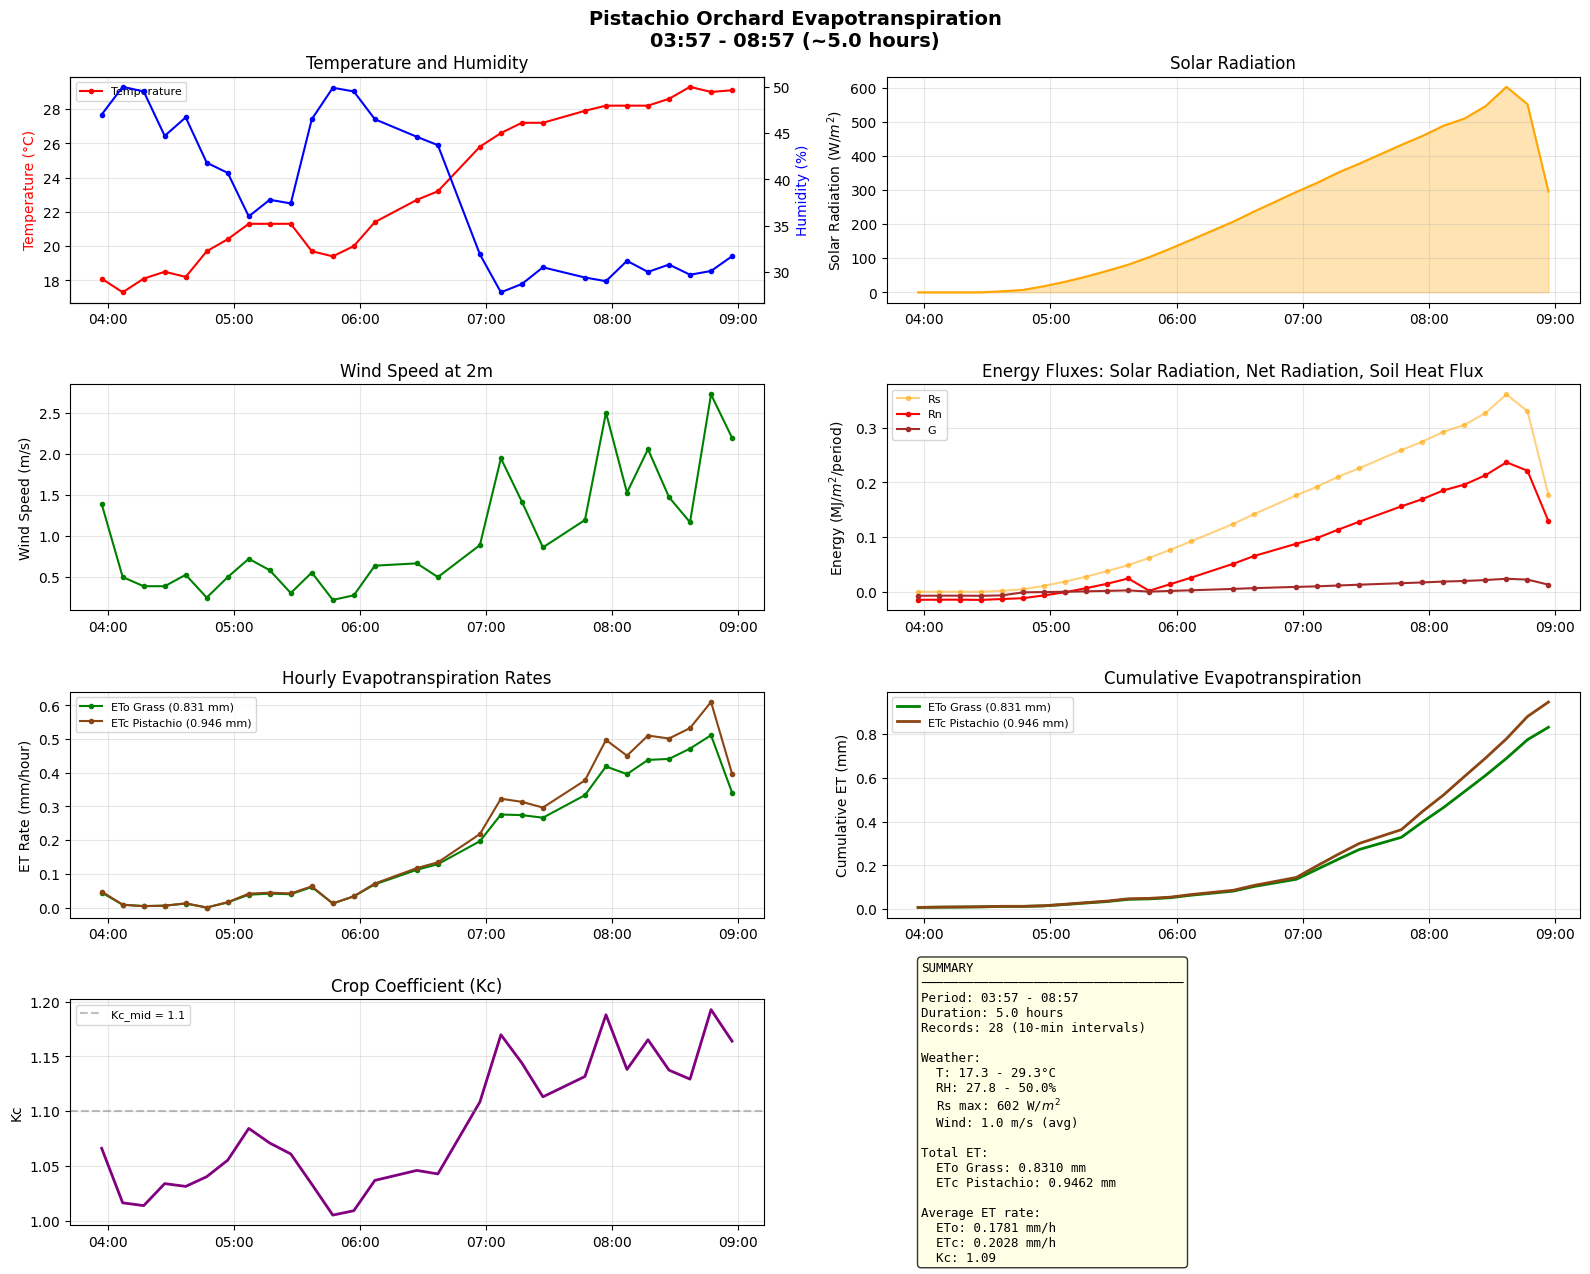


Summary image saved as 'pistachio_simulation_summary_weather-conditions1.png'


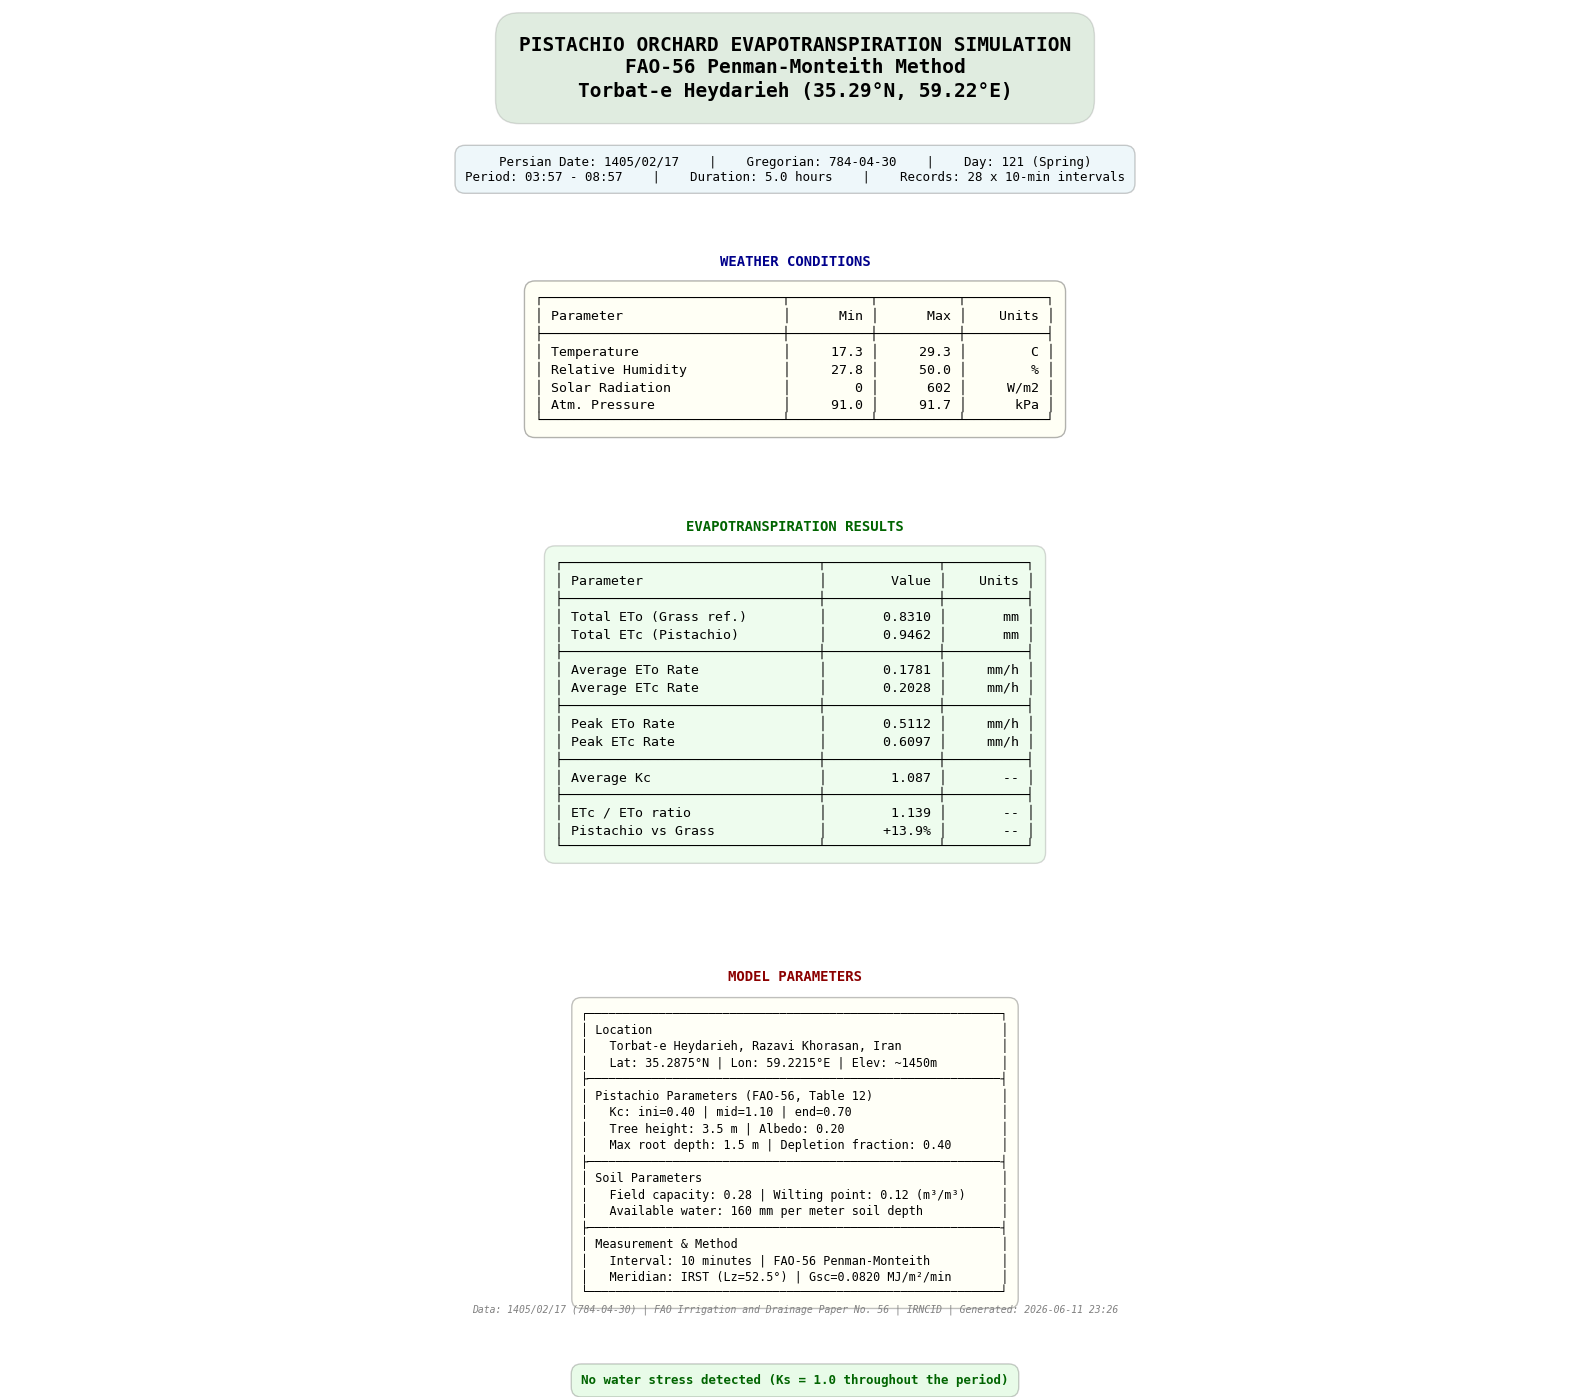


✓ Results exported to 'pistachio_et_results.csv'


,time,greenhouse,device,rain_mm,solar_Wm2,wind_dir,temp_C,humidity_pct,wind_kmh,pressure_kPa,...,cum_ETo,cum_ETc,Dr_mm,Ks,Zr_m,TAW_mm,RAW_mm,ETc_adj_mm_period,ETc_adj_mm_h,cum_ETc_adj
0,03:57 ...,گلخانه اردکانیان,دستگاه 1,376.8,0.0,--,18.1,47.0,5.0,91.0,...,0.007405,0.007894,0.0,1.0,0.300000,48.000000,19.200000,0.007894,0.047363,0.007894
1,04:07 ...,گلخانه اردکانیان,دستگاه 1,376.8,0.0,--,17.3,50.0,1.8,91.0,...,0.008766,0.009277,0.0,1.0,0.344444,55.111111,22.044444,0.001383,0.008297,0.009277
2,04:17 ...,گلخانه اردکانیان,دستگاه 1,376.8,0.0,--,18.1,49.5,1.4,91.1,...,0.009454,0.009975,0.0,1.0,0.388889,62.222222,24.888889,0.000698,0.004188,0.009975
3,04:27 ...,گلخانه اردکانیان,دستگاه 1,376.8,0.0,--,18.5,44.7,1.4,91.1,...,0.010343,0.010893,0.0,1.0,0.433333,69.333333,27.733333,0.000919,0.005512,0.010893
4,04:37 ...,گلخانه اردکانیان,دستگاه 1,376.8,3.0,--,18.2,46.7,1.9,91.1,...,0.012322,0.012935,0.0,1.0,0.477778,76.444444,30.577778,0.002041,0.012247,0.012935
5,04:47 ...,گلخانه اردکانیان,دستگاه 1,376.8,7.0,--,19.7,41.8,0.9,91.2,...,0.012322,0.012935,0.0,1.0,0.522222,83.555556,33.422222,0.000000,0.000000,0.012935
6,04:57 ...,گلخانه اردکانیان,دستگاه 1,376.8,18.0,--,20.4,40.7,1.8,91.2,...,0.014839,0.015590,0.0,1.0,0.566667,90.666667,36.266667,0.002656,0.015935,0.015590
7,05:07 ...,گلخانه اردکانیان,دستگاه 1,376.8,31.0,--,21.3,36.0,2.6,91.2,...,0.021164,0.022447,0.0,1.0,0.611111,97.777778,39.111111,0.006857,0.041143,0.022447
8,05:17 ...,گلخانه اردکانیان,دستگاه 1,376.8,46.0,--,21.3,37.8,2.1,91.3,...,0.028018,0.029787,0.0,1.0,0.655556,104.888889,41.955556,0.007339,0.044037,0.029787
9,05:27 ...,گلخانه اردکانیان,دستگاه 1,376.8,63.0,--,21.3,37.4,1.1,91.3,...,0.034588,0.036756,0.0,1.0,0.700000,112.000000,44.800000,0.006969,0.041817,0.036756


In [18]:
def main() -> pd.DataFrame | None:
    csv_file = "weather-conditions1.csv"
    
    try:
        print("=" * 70)
        print("PISTACHIO ORCHARD EVAPOTRANSPIRATION SIMULATION")
        print("FAO-56 Penman-Monteith Method")
        print("=" * 70)
        
        print(f"\nReading: {csv_file}")
        df = pd.read_csv(csv_file, encoding='utf-8')
        
        print(f"Data shape: {df.shape}")
        print(f"Columns: {df.columns.tolist()}")
        
        
        persian_year, persian_month, persian_day = extract_persian_date(df)
        
        if persian_year:
            greg_year, greg_month, greg_day = convert_persian_to_gregorian(
                persian_year, persian_month, persian_day
            )
            day_of_year = get_day_of_year(greg_year, greg_month, greg_day)
            
            persian_months = {
                1: 'Farvardin', 2: 'Ordibehesht', 3: 'Khordad',
                4: 'Tir', 5: 'Mordad', 6: 'Shahrivar',
                7: 'Mehr', 8: 'Aban', 9: 'Azar',
                10: 'Dey', 11: 'Bahman', 12: 'Esfand'
            }
            
            persian_date_str = f"{persian_year}/{persian_month:02d}/{persian_day:02d}"
            gregorian_date_str = f"{greg_year}-{greg_month:02d}-{greg_day:02d}"
            season = get_season(greg_month)
            
            print(f"\nDate detected: {persian_date_str} ({persian_months.get(persian_month, '?')})")
            print(f"Gregorian equivalent: {gregorian_date_str}")
            print(f"Day of year: {day_of_year}")
            print(f"Season: {season}")
        else:
            print("\nWarning: Could not detect date from data, using defaults")
            persian_date_str = "1405/02/17"
            gregorian_date_str = "2026-05-07"
            day_of_year = 127
            season = "Spring"
        
        df = simulate_ETc(csv_file, day_of_year=day_of_year)
        
        print("\n" + "=" * 70)
        print("SIMULATION RESULTS")
        print("=" * 70)
        print(f"Total ETo (Grass reference): {df['ETo_mm_period'].sum():.4f} mm")
        print(f"Total ETc (Pistachio):        {df['ETc_mm_period'].sum():.4f} mm")
        print(f"Average ETo rate:             {df['ETo_mm_h'].mean():.4f} mm/h")
        print(f"Average ETc rate:             {df['ETc_mm_h'].mean():.4f} mm/h")
        print(f"Peak ETo:                     {df['ETo_mm_h'].max():.4f} mm/h")
        print(f"Peak ETc:                     {df['ETc_mm_h'].max():.4f} mm/h")
        print(f"Average Kc:                   {df['Kc'].mean():.2f}")
        
        plot_results(df, filename=f"pistachio_et_simulation_{csv_file.removesuffix(".csv")}.png")
        print()
        
        create_summary_image(
            df=df,
            filename=f'pistachio_simulation_summary_{csv_file.removesuffix(".csv")}.png',
            persian_date=persian_date_str,
            gregorian_date=gregorian_date_str,
            day_of_year=day_of_year,
            season=season
        )
        
        export_cols = ['datetime', 'time_clean', 'temp_C', 'humidity_pct', 'solar_Wm2', 
                       'wind_kmh', 'pressure_kPa', 'Rn_MJ_period', 'G_MJ_period',
                       'ETo_mm_period', 'Kc', 'ETc_mm_period', 'ETo_mm_h', 'ETc_mm_h']
        
        available_cols = [col for col in export_cols if col in df.columns]
        df_out = df[available_cols].round(6)
        df_out.to_csv('pistachio_et_results.csv', index=False, encoding='utf-8')
        print("\n✓ Results exported to 'pistachio_et_results.csv'")
        
        return df
    
    except FileNotFoundError:
        print(f"\nError: File '{csv_file}' not found!")
        print("Please update the csv_file variable with the correct path.")
    except Exception as e:
        print(f"\nError: {e}")
        traceback.print_exc()

main()
